In [1]:
!pwd

/content


In [2]:
!git clone https://github.com/VictoryChianumba/robust-eeg-models

Cloning into 'robust-eeg-models'...
remote: Enumerating objects: 432, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 432 (delta 141), reused 145 (delta 119), pack-reused 258 (from 1)
Receiving objects: 100% (432/432), 215.98 MiB | 14.03 MiB/s, done.
Resolving deltas: 100% (264/264), done.
Updating files: 100% (190/190), done.


In [2]:
%cd /content/robust-eeg-models
!ls

/content/robust-eeg-models
attack		       explainability  my_kfold_results.png  results
BCICIV_2a_gdf	       gs_100_trials   notebooks	     test.py
BCIIV2a_convnet.ipynb  gs_30_trials    process_all.py	     training
data_test.ipynb        LICENCE	       randomtestfile.py     utils
environment.yml        main.py	       README.md
evaluation	       models	       requirements.txt


In [13]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	DeepConvNet_final_all_trials.csv
	DeepConvNet_final_best_results.json
	DeepConvNet_final_study.pkl
	DeepConvNet_study.db
	DeepConvNet_trial_50_all_trials.csv
	DeepConvNet_trial_50_best_results.json
	DeepConvNet_trial_50_study.pkl
	DeepConvNet_trial_55_all_trials.csv
	DeepConvNet_trial_55_best_results.json
	DeepConvNet_trial_55_study.pkl
	DeepConvNet_trial_60_all_trials.csv
	DeepConvNet_trial_60_best_results.json
	DeepConvNet_trial_60_study.pkl
	DeepConvNet_trial_65_all_trials.csv
	DeepConvNet_trial_65_best_results.json
	DeepConvNet_trial_65_study.pkl
	DeepConvNet_trial_70_all_trials.csv
	DeepConvNet_trial_70_best_results.json
	DeepConvNet_trial_70_study.pkl
	DeepConvNet_trial_75_all_trials.csv
	DeepConvNet_trial_75_best_results.json
	DeepConvNet_trial_75_study.pkl
	DeepConvNet_trial_80_all_trials.csv
	DeepConvNet_trial_80_best_results.json
	De

In [3]:
!git config --global user.email "chianumbav@gmial.com"
!git config --global user.name "Victory Chianumba"


In [14]:
!git add .
!git commit -m 'new deepconvnet study'
!git push origin main

[main 485f7d3] new deepconvnet study
 34 files changed, 967 insertions(+)
 create mode 100644 DeepConvNet_final_all_trials.csv
 create mode 100644 DeepConvNet_final_best_results.json
 create mode 100644 DeepConvNet_final_study.pkl
 create mode 100644 DeepConvNet_study.db
 create mode 100644 DeepConvNet_trial_50_all_trials.csv
 create mode 100644 DeepConvNet_trial_50_best_results.json
 create mode 100644 DeepConvNet_trial_50_study.pkl
 create mode 100644 DeepConvNet_trial_55_all_trials.csv
 create mode 100644 DeepConvNet_trial_55_best_results.json
 create mode 100644 DeepConvNet_trial_55_study.pkl
 create mode 100644 DeepConvNet_trial_60_all_trials.csv
 create mode 100644 DeepConvNet_trial_60_best_results.json
 create mode 100644 DeepConvNet_trial_60_study.pkl
 create mode 100644 DeepConvNet_trial_65_all_trials.csv
 create mode 100644 DeepConvNet_trial_65_best_results.json
 create mode 100644 DeepConvNet_trial_65_study.pkl
 create mode 100644 DeepConvNet_trial_70_all_trials.csv
 create 

In [15]:
import pandas as pd
folder = 'gs_100_trials'
deepconvnet_df = pd.read_csv(f'{folder}/DeepConvNet_final_all_trials.csv')
eegnet_df = pd.read_csv(f'{folder}/EEGNet_final_all_trials.csv')

In [16]:
deepconvnet_params = deepconvnet_df[deepconvnet_df['value']==deepconvnet_df['value'].max()]
deepconvnet_params

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout,params_lr,params_weight_decay,state
75,75,0.607522,2025-07-12 13:05:43.029084,2025-07-12 13:08:45.777765,0 days 00:03:02.748681,16,0.10954,0.004433,0.000001,COMPLETE


In [17]:
eegnet_params = eegnet_df[eegnet_df['value']==eegnet_df['value'].max()]
eegnet_params

,number,value,datetime_start,datetime_complete,duration,params_D,params_F1,params_batch_size,params_dropout,params_lr,params_weight_decay,state
11,11,0.633558,2025-07-12 09:06:44.216542,2025-07-12 09:19:15.521150,0 days 00:12:31.304608,8,32,32,0.202662,0.000384,0.004032,COMPLETE


In [5]:
!pip install torch torchvision torchaudio
!pip install mne moabb
!pip install torch-lr-finder
!pip install optuna


In [6]:
import torch
import importlib
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import optuna

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

from models.eegnet import EEGNet
from models.deepconvnet import DeepConvNet
from models.CNN import CNN
from models.EEGTransformer import EEGTransformer
from models.MultiscaleEEG import MultiScaleEEGTransformer

from utils.eeg_augmentations import EEGAugmentation

from training.run_optimization import run_optimization




In [7]:

def load_best_params_from_db(model_type='EEGNet'):
    """Load best parameters from Optuna database"""

    # Load the study from database
    study = optuna.load_study(
        study_name=f'{model_type}_optimization',
        storage=f'sqlite:///{model_type}_study.db'
    )

    print(f"📊 {model_type} Study Summary:")
    print(f"   Number of trials: {len(study.trials)}")
    print(f"   Best value: {study.best_value:.6f}")
    print(f"   Best trial number: {study.best_trial.number}")

    return study.best_params, study.best_value, study

# Load your results
eegnet_params, eegnet_score, eegnet_study = load_best_params_from_db('EEGNet')
deepconv_params, deepconv_score, deepconv_study = load_best_params_from_db('DeepConvNet')

print("🏆 EEGNet Best Parameters:")
for param, value in eegnet_params.items():
    print(f"   {param}: {value}")

print("\n🏆 DeepConvNet Best Parameters:")
for param, value in deepconv_params.items():
    print(f"   {param}: {value}")

📊 EEGNet Study Summary:
   Number of trials: 100
   Best value: 0.633558
   Best trial number: 11
📊 DeepConvNet Study Summary:
   Number of trials: 100
   Best value: 0.607522
   Best trial number: 75
🏆 EEGNet Best Parameters:
   batch_size: 32
   lr: 0.00038415470166584304
   weight_decay: 0.0040320784779631575
   dropout: 0.2026621728298541
   F1: 32
   D: 8

🏆 DeepConvNet Best Parameters:
   batch_size: 16
   lr: 0.0044328385489627
   weight_decay: 1.0003615073729024e-06
   dropout: 0.10954031672781599


In [ ]:

def create_optimized_models_from_db():
    """Create optimized models directly from database parameters"""

    # Load studies
    eegnet_study = optuna.load_study(
        study_name='EEGNet_optimization',
        storage='sqlite:///EEGNet_study.db'
    )

    deepconv_study = optuna.load_study(
        study_name='DeepConvNet_optimization',
        storage='sqlite:///DeepConvNet_study.db'
    )

    # Extract best parameters
    eegnet_params = eegnet_study.best_params
    deepconv_params = deepconv_study.best_params

    # Create optimized models
    optimized_eegnet = EEGNet(
        num_classes=4,
        channels=22,
        samples=1001,
        F1=eegnet_params['F1'],
        D=eegnet_params['D'],
        dropout=eegnet_params['dropout']
    )

    optimized_deepconvnet = DeepConvNet(
        num_classes=4,
        channels=22,
        samples=1125,  # Adjust based on your data
        dropout=deepconv_params['dropout']
    )

    # Return models and training parameters
    training_params = {
        'eegnet': {
            'lr': eegnet_params['lr'],
            'weight_decay': eegnet_params['weight_decay'],
            'batch_size': eegnet_params['batch_size']
        },
        'deepconv': {
            'lr': deepconv_params['lr'],
            'weight_decay': deepconv_params['weight_decay'],
            'batch_size': deepconv_params['batch_size']
        }
    }

    return optimized_eegnet, optimized_deepconvnet, training_params

# Create your optimized models
eegnet_model, deepconv_model, train_params = create_optimized_models_from_db()

In [ ]:
eegnet_model

EEGNet(
  (firstconv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(1, 51), stride=(1, 1), padding=(0, 25), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (depthwiseConv): Sequential(
    (0): Conv2d(32, 256, kernel_size=(22, 1), stride=(1, 1), groups=32, bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.2026621728298541, inplace=False)
  )
  (separableConv): Sequential(
    (0): Conv2d(256, 256, kernel_size=(1, 15), stride=(1, 1), padding=(0, 7), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (4): Dropout(p=0.2026621728298541, inplace=False)
  )
  (classify): Linear(in_features=7936, out_features=4, bias=True)
)

In [ ]:
def analyze_optimization_results(study):
    """Analyze the full optimization results"""

    # Convert to DataFrame for analysis
    trials_df = study.trials_dataframe()

    # Basic statistics
    print(f"📈 Optimization Analysis:")
    print(f"   Total trials: {len(trials_df)}")
    print(f"   Completed trials: {len(trials_df[trials_df['state'] == 'COMPLETE'])}")
    print(f"   Best value: {study.best_value:.6f}")
    print(f"   Worst value: {trials_df['value'].min():.6f}")
    print(f"   Mean value: {trials_df['value'].mean():.6f}")
    print(f"   Std value: {trials_df['value'].std():.6f}")

    # Parameter importance
    print(f"\n🎯 Parameter Importance:")
    try:
        param_importance = optuna.importance.get_param_importances(study)
        for param, importance in param_importance.items():
            print(f"   {param}: {importance:.4f}")
    except:
        print("   Could not calculate parameter importance")

    # Top 5 trials
    print(f"\n🏆 Top 5 Trials:")
    top_trials = trials_df.nlargest(5, 'value')
    for idx, trial in top_trials.iterrows():
        print(f"   Trial {trial['number']}: {trial['value']:.6f}")

    return trials_df

# Analyze your studies
print('EEGNet Analysis:')
eegnet_analysis = analyze_optimization_results(eegnet_study)
print('\nDeepConvNet Analysis:')
deepconv_analysis = analyze_optimization_results(deepconv_study)


EEGNet Analysis:
📈 Optimization Analysis:
   Total trials: 100
   Completed trials: 20
   Best value: 0.633558
   Worst value: 0.254581
   Mean value: 0.447570
   Std value: 0.094422

🎯 Parameter Importance:
   lr: 0.2404
   dropout: 0.2095
   D: 0.1998
   F1: 0.1830
   batch_size: 0.1360
   weight_decay: 0.0313

🏆 Top 5 Trials:
   Trial 11: 0.633558
   Trial 10: 0.627772
   Trial 13: 0.622951
   Trial 56: 0.615236
   Trial 69: 0.615236

DeepConvNet Analysis:
📈 Optimization Analysis:
   Total trials: 100
   Completed trials: 28
   Best value: 0.607522
   Worst value: 0.254581
   Mean value: 0.405506
   Std value: 0.101375

🎯 Parameter Importance:
   lr: 0.4191
   batch_size: 0.3624
   dropout: 0.1627
   weight_decay: 0.0558

🏆 Top 5 Trials:
   Trial 75: 0.607522
   Trial 50: 0.596914
   Trial 39: 0.592093
   Trial 94: 0.589200
   Trial 16: 0.583414


In [8]:
# ---------- Config ----------
subject_id = 8
batch_size = 32
epochs = 200
lr = 0.0001
lr = {
    "EEGNet": 0.0001,
    "DeepConvNet": 0.00025,
    "CNN": 0.0001,
    "EEGTransformer": 0.0001,
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [9]:
# Replace your entire preprocessing with:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

ds = BNCI2014_001()
paradigm = MotorImagery(n_classes=4)
X, labels, meta = paradigm.get_data(dataset=ds, subjects=[1, 2, 3, 4, 5, 6, 7, 8, 9])  # Single subject first

/usr/local/lib/python3.11/dist-packages/moabb/datasets/download.py:56: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))


MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 60.9GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|█████████████████████████████████████| 43.8M/43.8M [

In [10]:
print(f"Raw data shape: {X.shape}")
print(f"Labels: {np.unique(labels)}")

# 2. CONVERT LABELS TO NUMERIC (like supervisor)
class_map = {'left_hand': 0, 'right_hand': 1, 'feet': 2, 'tongue': 3}
y_numeric = np.array([class_map[label] for label in labels])

# 3. APPLY YOUR LABEL CLEANING LOGIC
y = y_numeric.copy()

# Filter out any invalid samples (e.g., negative class labels)
valid_mask = y >= 0
X = X[valid_mask]
y = y[valid_mask]

# Debug: Check what labels look like
print("Original labels:", np.unique(y), "min:", y.min(), "max:", y.max())

# Remap labels to start from 0 (though they should already be 0-3)
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y = np.vectorize(label_map.get)(y)

print("Cleaned labels:", np.unique(y), "min:", y.min(), "max:", y.max())

# 4. PREPARE FOR PYTORCH (like supervisor)
X = torch.tensor(X, dtype=torch.float32)  # Add channel dimension
y = torch.tensor(y, dtype=torch.long)

X=X.unsqueeze(axis=1)

print(f"Final tensor shapes: X={X.shape}, y={y.shape}")
print(f"Shapes of the objects: X={X.dtype}, y={y.dtype}")


Raw data shape: (5184, 22, 1001)
Labels: ['feet' 'left_hand' 'right_hand' 'tongue']
Original labels: [0 1 2 3] min: 0 max: 3
Cleaned labels: [0 1 2 3] min: 0 max: 3
Final tensor shapes: X=torch.Size([5184, 1, 22, 1001]), y=torch.Size([5184])
Shapes of the objects: X=torch.float32, y=torch.int64


In [11]:
X /= X.std()

In [ ]:
eegnet_study = run_optimization(X, y, model_type='EEGNet', n_trials=50)

[I 2025-07-12 08:21:50,266] A new study created in RDB with name: EEGNet_optimization
[I 2025-07-12 08:25:29,145] Trial 0 finished with value: 0.5785920925747348 and parameters: {'batch_size': 64, 'lr': 0.0075400494265803605, 'weight_decay': 0.00708965874897669, 'dropout': 0.15585409000149056, 'F1': 8, 'D': 2}. Best is trial 0 with value: 0.5785920925747348.
[I 2025-07-12 08:29:44,223] Trial 1 finished with value: 0.5641272902603665 and parameters: {'batch_size': 16, 'lr': 6.383347151549101e-05, 'weight_decay': 0.0008044804754247862, 'dropout': 0.3823635604322432, 'F1': 16, 'D': 4}. Best is trial 0 with value: 0.5785920925747348.
[I 2025-07-12 08:33:47,488] Trial 2 finished with value: 0.5583413693346191 and parameters: {'batch_size': 16, 'lr': 5.5926671831956264e-05, 'weight_decay': 9.785784039544072e-06, 'dropout': 0.4812285674151898, 'F1': 16, 'D': 4}. Best is trial 0 with value: 0.5785920925747348.
[I 2025-07-12 08:38:46,729] Trial 3 finished with value: 0.5072324011571842 and para

✅ Study saved as:
  - EEGNet_trial_50_study.pkl (full study)
  - EEGNet_trial_50_best_results.json (best config)
  - EEGNet_trial_50_all_trials.csv (all trials)
💾 Progress saved at trial 50


[I 2025-07-12 10:19:28,200] Trial 51 pruned. 
[I 2025-07-12 10:19:37,390] Trial 52 pruned. 
[I 2025-07-12 10:19:46,155] Trial 53 pruned. 
[I 2025-07-12 10:20:03,339] Trial 54 pruned. 
[I 2025-07-12 10:20:20,749] Trial 55 pruned. 


✅ Study saved as:
  - EEGNet_trial_55_study.pkl (full study)
  - EEGNet_trial_55_best_results.json (best config)
  - EEGNet_trial_55_all_trials.csv (all trials)
💾 Progress saved at trial 55


[I 2025-07-12 10:30:15,149] Trial 56 finished with value: 0.6152362584378014 and parameters: {'batch_size': 32, 'lr': 0.00015891901709438983, 'weight_decay': 0.0008833863404531206, 'dropout': 0.22912182028238054, 'F1': 32, 'D': 8}. Best is trial 11 with value: 0.6335583413693346.
[I 2025-07-12 10:30:33,015] Trial 57 pruned. 
[I 2025-07-12 10:30:50,510] Trial 58 pruned. 
[I 2025-07-12 10:31:08,704] Trial 59 pruned. 
[I 2025-07-12 10:31:26,077] Trial 60 pruned. 


...

✅ Study saved as:
  - EEGNet_trial_90_study.pkl (full study)
  - EEGNet_trial_90_best_results.json (best config)
  - EEGNet_trial_90_all_trials.csv (all trials)
💾 Progress saved at trial 90


[I 2025-07-12 11:38:57,817] Trial 91 pruned. 
[I 2025-07-12 11:40:08,184] Trial 92 pruned. 
[I 2025-07-12 11:42:29,800] Trial 93 pruned. 
[I 2025-07-12 11:42:47,441] Trial 94 pruned. 
[I 2025-07-12 11:43:57,847] Trial 95 pruned. 


✅ Study saved as:
  - EEGNet_trial_95_study.pkl (full study)
  - EEGNet_trial_95_best_results.json (best config)
  - EEGNet_trial_95_all_trials.csv (all trials)
💾 Progress saved at trial 95


[I 2025-07-12 11:46:54,489] Trial 96 pruned. 
[I 2025-07-12 11:47:10,254] Trial 97 pruned. 
[I 2025-07-12 11:47:26,848] Trial 98 pruned. 
[I 2025-07-12 11:47:31,091] Trial 99 pruned. 


✅ Study saved as:
  - EEGNet_final_study.pkl (full study)
  - EEGNet_final_best_results.json (best config)
  - EEGNet_final_all_trials.csv (all trials)


In [12]:
deepconvnet_study = run_optimization(X, y, model_type='DeepConvNet', n_trials=50)

[I 2025-07-17 08:27:42,499] A new study created in RDB with name: DeepConvNet_optimization
[I 2025-07-17 08:30:35,070] Trial 0 finished with value: 0.5650916104146577 and parameters: {'batch_size': 32, 'lr': 4.866630572108026e-05, 'weight_decay': 0.0015816192911221009, 'dropout': 0.3897396948721591}. Best is trial 0 with value: 0.5650916104146577.
[I 2025-07-17 08:31:55,921] Trial 1 finished with value: 0.5853423336547734 and parameters: {'batch_size': 32, 'lr': 0.008306503163838595, 'weight_decay': 1.9951203763304294e-05, 'dropout': 0.17096517962852933}. Best is trial 1 with value: 0.5853423336547734.
[I 2025-07-17 08:34:38,098] Trial 2 finished with value: 0.39633558341369335 and parameters: {'batch_size': 64, 'lr': 1.1475686445208673e-05, 'weight_decay': 0.0012673380125875497, 'dropout': 0.3775223163514091}. Best is trial 1 with value: 0.5853423336547734.
[I 2025-07-17 08:37:20,122] Trial 3 finished with value: 0.6084860173577628 and parameters: {'batch_size': 64, 'lr': 0.0014984567

✅ Study saved as:
  - DeepConvNet_trial_50_study.pkl (full study)
  - DeepConvNet_trial_50_best_results.json (best config)
  - DeepConvNet_trial_50_all_trials.csv (all trials)
💾 Progress saved at trial 50


[I 2025-07-17 09:01:54,862] Trial 51 pruned. 
[I 2025-07-17 09:02:08,352] Trial 52 pruned. 
[I 2025-07-17 09:02:28,541] Trial 53 pruned. 
[I 2025-07-17 09:02:31,991] Trial 54 pruned. 
[I 2025-07-17 09:02:38,831] Trial 55 pruned. 


✅ Study saved as:
  - DeepConvNet_trial_55_study.pkl (full study)
  - DeepConvNet_trial_55_best_results.json (best config)
  - DeepConvNet_trial_55_all_trials.csv (all trials)
💾 Progress saved at trial 55


[I 2025-07-17 09:02:42,179] Trial 56 pruned. 
[I 2025-07-17 09:03:02,396] Trial 57 pruned. 
[I 2025-07-17 09:03:52,884] Trial 58 pruned. 
[I 2025-07-17 09:03:56,752] Trial 59 pruned. 
[I 2025-07-17 09:04:00,194] Trial 60 pruned. 


...

✅ Study saved as:
  - DeepConvNet_trial_90_study.pkl (full study)
  - DeepConvNet_trial_90_best_results.json (best config)
  - DeepConvNet_trial_90_all_trials.csv (all trials)
💾 Progress saved at trial 90


[I 2025-07-17 09:16:25,370] Trial 91 pruned. 
[I 2025-07-17 09:17:15,794] Trial 92 pruned. 
[I 2025-07-17 09:17:19,307] Trial 93 pruned. 
[I 2025-07-17 09:17:36,192] Trial 94 pruned. 
[I 2025-07-17 09:17:56,479] Trial 95 pruned. 


✅ Study saved as:
  - DeepConvNet_trial_95_study.pkl (full study)
  - DeepConvNet_trial_95_best_results.json (best config)
  - DeepConvNet_trial_95_all_trials.csv (all trials)
💾 Progress saved at trial 95


[I 2025-07-17 09:18:07,984] Trial 96 pruned. 
[I 2025-07-17 09:18:11,309] Trial 97 pruned. 
[I 2025-07-17 09:18:31,597] Trial 98 pruned. 
[I 2025-07-17 09:19:25,594] Trial 99 pruned. 


✅ Study saved as:
  - DeepConvNet_final_study.pkl (full study)
  - DeepConvNet_final_best_results.json (best config)
  - DeepConvNet_final_all_trials.csv (all trials)


In [13]:
# ------------- Train test split -------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
X_train.shape,  y_train.shape, X_train.dtype, y_train.dtype

(torch.Size([4147, 1, 22, 1001]),
 torch.Size([4147]),
 torch.float32,
 torch.int64)

In [15]:
X_train.shape

torch.Size([4147, 1, 22, 1001])

In [16]:
# wrap in Dataloader
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [17]:
input_shape = X.shape[1:]  # (channels, time_points)
num_classes = len(torch.unique(y)+1)
# model = CNN(input_shape, num_classes).to(device)
model = DeepConvNet(num_classes=len(torch.unique(torch.tensor(y))), channels=X.shape[2], samples=X.shape[3] ).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr['DeepConvNet'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)
eeg_augment = EEGAugmentation(prob=0.1)


/tmp/ipython-input-17-3317609853.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model = DeepConvNet(num_classes=len(torch.unique(torch.tensor(y))), channels=X.shape[2], samples=X.shape[3] ).to(device)


In [23]:
DeepConvNet()

DeepConvNet(
  (conv_temporal): Conv2d(1, 25, kernel_size=(1, 10), stride=(1, 1))
  (conv_spatial): Conv2d(25, 25, kernel_size=(22, 1), stride=(1, 1))
  (bnorm1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (elu1): ELU(alpha=1.0)
  (pool1): MaxPool2d(kernel_size=(1, 3), stride=(1, 3), padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.5, inplace=False)
  (conv2): Conv2d(25, 50, kernel_size=(1, 10), stride=(1, 1))
  (bnorm2): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (elu2): ELU(alpha=1.0)
  (pool2): MaxPool2d(kernel_size=(1, 3), stride=(1, 3), padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (conv3): Conv2d(50, 100, kernel_size=(1, 10), stride=(1, 1))
  (bnorm3): BatchNorm2d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (elu3): ELU(alpha=1.0)
  (pool3): MaxPool2d(kernel_size=(1, 3), stride=(1, 3), padding=0, dilation=1, ceil_mode=Fal

In [18]:
train_losses = []
val_losses = []
val_accuracies = []

# Early stopping
best_val_acc = 0.0
patience_counter = 0
patience = 25

for epoch in range(epochs):

    #training
    model.train()
    running_loss = 0.0
    train_total = 0
    tcorrect = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # # Apply EEG augmentation to entire batch
        # if epoch > 40:  # Start augmentation after initial learning
        #     batch_X_np = batch_X.cpu().numpy()
        #     batch_X_aug = eeg_augment(batch_X_np)  # Your existing augmentation
        #     batch_X = torch.tensor(batch_X_aug, dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()

        # Add gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

        # train accuracies
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        tcorrect += (predicted == batch_y).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = tcorrect / train_total

    # VALIDATION - Your existing code
    val_running_loss = 0.0
    model.eval()
    vcorrect = 0
    val_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            vcorrect += (predicted == batch_y).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = vcorrect / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(val_loss)

    # Early stopping
    # if val_accuracy > best_val_acc:
    #     best_val_acc = val_accuracy
    #     patience_counter = 0
    # else:
    #     patience_counter += 1

    # if patience_counter >= patience:
    #     print(f"Early stopping at epoch {epoch+1}")
    #     break



    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f} - Train Acc:{train_accuracy:.4f} - Val Loss: {val_loss:.4f}- Val Acc: {val_accuracy:.4f}")

print("✅ Training complete.")


Epoch [1/200] - Train Loss: 1.5482 - Train Acc:0.2684 - Val Loss: 1.3892- Val Acc: 0.2642
Epoch [2/200] - Train Loss: 1.5200 - Train Acc:0.2643 - Val Loss: 1.4095- Val Acc: 0.2584
Epoch [3/200] - Train Loss: 1.4772 - Train Acc:0.2853 - Val Loss: 1.3601- Val Acc: 0.3047
Epoch [4/200] - Train Loss: 1.4241 - Train Acc:0.3096 - Val Loss: 1.3675- Val Acc: 0.3057
Epoch [5/200] - Train Loss: 1.3990 - Train Acc:0.3260 - Val Loss: 1.3417- Val Acc: 0.3375
Epoch [6/200] - Train Loss: 1.3744 - Train Acc:0.3395 - Val Loss: 1.3386- Val Acc: 0.3250
Epoch [7/200] - Train Loss: 1.3402 - Train Acc:0.3470 - Val Loss: 1.3064- Val Acc: 0.3983
Epoch [8/200] - Train Loss: 1.3160 - Train Acc:0.3716 - Val Loss: 1.2294- Val Acc: 0.4176
Epoch [9/200] - Train Loss: 1.2421 - Train Acc:0.4367 - Val Loss: 1.2443- Val Acc: 0.4002
Epoch [10/200] - Train Loss: 1.2225 - Train Acc:0.4413 - Val Loss: 1.1889- Val Acc: 0.4474
Epoch [11/200] - Train Loss: 1.1910 - Train Acc:0.4613 - Val Loss: 1.1856- Val Acc: 0.4436
Epoch [1

In [ ]:
def train_optimized_models(eegnet_model, deepconv_model, train_params,
                          X_train, y_train, X_val, y_val, epochs=100):
    """Train both models with their optimized hyperparameters"""

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Setup models
    eegnet_model.to(device)
    deepconv_model.to(device)

    # Setup optimizers with optimized parameters
    eegnet_optimizer = torch.optim.Adam(
        eegnet_model.parameters(),
        lr=train_params['eegnet']['lr'],
        weight_decay=train_params['eegnet']['weight_decay']
    )

    deepconv_optimizer = torch.optim.Adam(
        deepconv_model.parameters(),
        lr=train_params['deepconv']['lr'],
        weight_decay=train_params['deepconv']['weight_decay']
    )

    # Setup data loaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))

    eegnet_train_loader = DataLoader(train_dataset, batch_size=train_params['eegnet']['batch_size'], shuffle=True)
    eegnet_val_loader = DataLoader(val_dataset, batch_size=train_params['eegnet']['batch_size'], shuffle=False)

    deepconv_train_loader = DataLoader(train_dataset, batch_size=train_params['deepconv']['batch_size'], shuffle=True)
    deepconv_val_loader = DataLoader(val_dataset, batch_size=train_params['deepconv']['batch_size'], shuffle=False)

    # Setup other training components
    criterion = torch.nn.CrossEntropyLoss()

    eegnet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(eegnet_optimizer, 'min', patience=5)
    deepconv_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(deepconv_optimizer, 'min', patience=5)

    # Train EEGNet
    print("🚀 Training EEGNet with optimized parameters...")
    eegnet_model = train_single_model(
        eegnet_model, eegnet_train_loader, eegnet_val_loader,
        eegnet_optimizer, eegnet_scheduler, criterion, device, epochs, "EEGNet"
    )

    # Train DeepConvNet
    print("🚀 Training DeepConvNet with optimized parameters...")
    deepconv_model = train_single_model(
        deepconv_model, deepconv_train_loader, deepconv_val_loader,
        deepconv_optimizer, deepconv_scheduler, criterion, device, epochs, "DeepConvNet"
    )

    return eegnet_model, deepconv_model

def train_single_model(model, train_loader, val_loader, optimizer, scheduler,
                      criterion, device, epochs, model_name):
    """Train a single model with the optimized hyperparameters"""

    best_val_acc = 0.0
    patience_counter = 0
    patience = 20

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total

        scheduler.step(val_loss)

        # # Early stopping
        # if val_accuracy > best_val_acc:
        #     best_val_acc = val_accuracy
        #     patience_counter = 0
        #     # Save best model
        #     torch.save(model.state_dict(), f'best_{model_name.lower()}_model.pth')
        # else:
        #     patience_counter += 1

        # if patience_counter >= patience:
        #     print(f"Early stopping for {model_name} at epoch {epoch+1}")
        #     break

        if epoch % 10 == 0:
            print(f"{model_name} Epoch [{epoch+1}/{epochs}] - Train Acc: {train_accuracy:.4f} - Val Acc: {val_accuracy:.4f}")

    # Load best model
    model.load_state_dict(torch.load(f'best_{model_name.lower()}_model.pth'))
    print(f"✅ {model_name} training complete. Best validation accuracy: {best_val_acc:.4f}")

    return model

In [ ]:
# Complete setup and training
def setup_and_train_optimized_models(X_train, y_train, X_val, y_val):
    """Complete setup and training pipeline"""

    # Load optimized models and parameters from database
    eegnet_model, deepconv_model, train_params = create_optimized_models_from_db()

    print("📋 Using optimized hyperparameters:")
    print(f"EEGNet: lr={train_params['eegnet']['lr']}, wd={train_params['eegnet']['weight_decay']}, bs={train_params['eegnet']['batch_size']}")
    print(f"DeepConvNet: lr={train_params['deepconv']['lr']}, wd={train_params['deepconv']['weight_decay']}, bs={train_params['deepconv']['batch_size']}")

    # Train models with optimized hyperparameters
    trained_eegnet, trained_deepconv = train_optimized_models(
        eegnet_model, deepconv_model, train_params,
        X_train, y_train, X_val, y_val, epochs=100
    )

    return trained_eegnet, trained_deepconv, train_params

# Run the complete pipeline
trained_eegnet, trained_deepconv, training_parameters = setup_and_train_optimized_models(
    X_train, y_train, X_val, y_val
)

📋 Using optimized hyperparameters:
EEGNet: lr=0.00038415470166584304, wd=0.0040320784779631575, bs=32
DeepConvNet: lr=0.0044328385489627, wd=1.0003615073729024e-06, bs=16
🚀 Training EEGNet with optimized parameters...
EEGNet Epoch [1/100] - Train Acc: 0.3738 - Val Acc: 0.4349
EEGNet Epoch [11/100] - Train Acc: 0.6865 - Val Acc: 0.5738
EEGNet Epoch [21/100] - Train Acc: 0.6402 - Val Acc: 0.5844
EEGNet Epoch [31/100] - Train Acc: 0.7010 - Val Acc: 0.6268
EEGNet Epoch [41/100] - Train Acc: 0.6974 - Val Acc: 0.6220
EEGNet Epoch [51/100] - Train Acc: 0.6998 - Val Acc: 0.6336
EEGNet Epoch [61/100] - Train Acc: 0.7029 - Val Acc: 0.6278
EEGNet Epoch [71/100] - Train Acc: 0.7138 - Val Acc: 0.6307
Early stopping for EEGNet at epoch 74
✅ EEGNet training complete. Best validation accuracy: 0.6393
🚀 Training DeepConvNet with optimized parameters...
DeepConvNet Epoch [1/100] - Train Acc: 0.3212 - Val Acc: 0.3684
DeepConvNet Epoch [11/100] - Train Acc: 0.5134 - Val Acc: 0.4667
DeepConvNet Epoch [21/1

In [ ]:

# create results folders dynamically
model_name = "DeepConvNet"
base_dir = f"results/{model_name}"

plots_dir = f"{base_dir}/plots"
checkpoint_dir = f"{base_dir}/checkpoints"

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

print("Created:", base_dir)


Created: results/DeepConvNet


In [ ]:
from datetime import datetime

# Plot loss
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{model_name} Training Loss")
plt.legend()
# plt.savefig(os.path.join(plots_dir, f"{model_name}_train_loss.png"))
plt.close()

# Plot accuracy
plt.figure()
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{model_name} Validation Accuracy")
plt.legend()
# plt.savefig(os.path.join(plots_dir, f"{model_name}_val_accuracy.png"))
plt.close()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_{timestamp}.pth")

In [ ]:
cm = confusion_matrix(all_labels, all_preds)


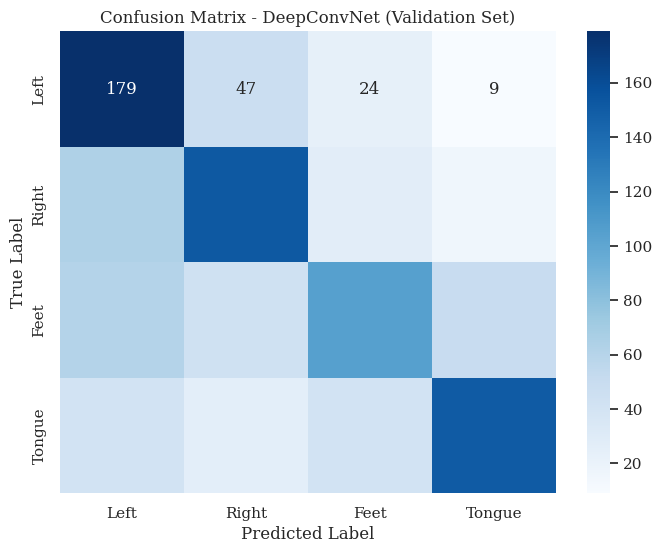

In [ ]:


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['Left', 'Right', 'Feet', 'Tongue'],
    yticklabels=['Left', 'Right', 'Feet', 'Tongue']
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DeepConvNet (Validation Set)")
plt.savefig(os.path.join(plots_dir, f"{model_name}_confusion_matrix.png"))
plt.show()


In [ ]:
# Test all architectures
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Basic EEG Transformer
model1 = EEGTransformer(num_classes=4, channels=22, samples=1001).to(device)

# Multi-scale version
model2 = MultiScaleEEGTransformer(num_classes=4, channels=22, samples=1001).to(device)

# Vision Transformer style
model3 = EEGViT(num_classes=4, channels=22, samples=1001).to(device)

# Test with your data
for model_name, model in [("EEGTransformer", model1),
                         ("MultiScale", model2),
                         ("EEGViT", model3)]:
    # Test forward pass
    test_input = torch.randn(4, 1, 22, 1001).to(device)
    output = model(test_input)
    print(f"{model_name}: Input {test_input.shape} -> Output {output.shape}")

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name} parameters: {total_params:,}")
    print()

EEGTransformer: Input torch.Size([4, 1, 22, 1001]) -> Output torch.Size([4, 4])
EEGTransformer parameters: 3,634,564

MultiScale: Input torch.Size([4, 1, 22, 1001]) -> Output torch.Size([4, 4])
MultiScale parameters: 7,426,564

EEGViT: Input torch.Size([4, 1, 22, 1001]) -> Output torch.Size([4, 4])
EEGViT parameters: 9,493,252



In [ ]:
import sqlite3
import pandas as pd
import os

def verify_database_contents(db_path):
    """Check what's in your database"""

    conn = sqlite3.connect(db_path)

    # Check tables
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print("📋 Database tables:")
    print(tables)

    # Check study info
    studies = pd.read_sql_query("SELECT * FROM studies;", conn)
    print("\n📊 Studies:")
    print(studies)

    # Check trial count
    trial_count = pd.read_sql_query("SELECT COUNT(*) as count FROM trials;", conn)
    print(f"\n🔢 Total trials: {trial_count['count'].iloc[0]}")

    conn.close()

# Verify your databases exist and have data
if os.path.exists('EEGNet_study.db'):
    print("EEGNet database found:")
    verify_database_contents('EEGNet_study.db')

if os.path.exists('DeepConvNet_study.db'):
    print("\nDeepConvNet database found:")
    verify_database_contents('DeepConvNet_study.db')

EEGNet database found:
📋 Database tables:
                         name
0                     studies
1                version_info
2            study_directions
3       study_user_attributes
4     study_system_attributes
5                      trials
6       trial_user_attributes
7     trial_system_attributes
8                trial_params
9                trial_values
10  trial_intermediate_values
11           trial_heartbeats
12            alembic_version

📊 Studies:
   study_id           study_name
0         1  EEGNet_optimization

🔢 Total trials: 100

DeepConvNet database found:
📋 Database tables:
                         name
0                     studies
1                version_info
2            study_directions
3       study_user_attributes
4     study_system_attributes
5                      trials
6       trial_user_attributes
7     trial_system_attributes
8                trial_params
9                trial_values
10  trial_intermediate_values
11           trial_heartbeats
1

In [ ]:
import torch.optim as optim

def train_transformer(model, model_name, train_loader, val_loader, device, epochs=200):
    """Train transformer model and return results"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)  # Lower LR for transformers

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0
    results = []

    print(f"\n=== Training {model_name} ===")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # Gradient clipping for transformers
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == batch_y).sum().item()
            train_total += batch_y.size(0)

        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

        val_acc = val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)

        # Update learning rate
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower()}_model.pth')

        # Store results
        results.append({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'train_acc': train_acc,
            'val_loss': avg_val_loss,
            'val_acc': val_acc,
            'lr': current_lr
        })

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch [{epoch+1}/{epochs}] - "
                  f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} - "
                  f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f} - "
                  f"LR: {current_lr:.7f}")

    print(f"{model_name} Best Validation Accuracy: {best_val_acc:.4f}")
    return results, best_val_acc

# Train all transformer models
transformer_results = {}

# Make sure you have train_loader and val_loader from your MOABB data
models_to_test = [
    ("EEGTransformer", EEGTransformer(num_classes=4, channels=22, samples=1001).to(device)),
    ("MultiScale", MultiScaleEEGTransformer(num_classes=4, channels=22, samples=1001).to(device)),
    ("EEGViT", EEGViT(num_classes=4, channels=22, samples=1001).to(device))
]

for model_name, model in models_to_test:
    results, best_acc = train_transformer(
        model, model_name, train_loader, val_loader, device, epochs=400
    )
    transformer_results[model_name] = {
        'results': results,
        'best_acc': best_acc,
        'params': sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

# Compare results
print("\n" + "="*60)
print("TRANSFORMER COMPARISON RESULTS")
print("="*60)

for model_name, data in transformer_results.items():
    print(f"{model_name:15} | Best Val Acc: {data['best_acc']:.4f} | Parameters: {data['params']:,}")

print("\nFor comparison with your previous models:")
print("- Random chance: ~25%")
print("- Your CNN/DeepConvNet: ~25% (not learning)")
print("- Supervisor's CNN: ~90% (but 2 classes)")


=== Training EEGTransformer ===
Epoch [1/400] - Train Loss: 1.4739, Train Acc: 0.1935 - Val Loss: 1.4052, Val Acc: 0.2586 - LR: 0.0001000
Epoch [6/400] - Train Loss: 1.3810, Train Acc: 0.3283 - Val Loss: 1.4102, Val Acc: 0.3190 - LR: 0.0000999
Epoch [11/400] - Train Loss: 1.1729, Train Acc: 0.4783 - Val Loss: 1.5062, Val Acc: 0.2672 - LR: 0.0000998
Epoch [16/400] - Train Loss: 0.9002, Train Acc: 0.6196 - Val Loss: 1.7598, Val Acc: 0.3534 - LR: 0.0000996
Epoch [21/400] - Train Loss: 0.6832, Train Acc: 0.7043 - Val Loss: 2.2957, Val Acc: 0.3190 - LR: 0.0000993
Epoch [26/400] - Train Loss: 0.3616, Train Acc: 0.8522 - Val Loss: 2.6173, Val Acc: 0.3707 - LR: 0.0000990
Epoch [31/400] - Train Loss: 0.4523, Train Acc: 0.8196 - Val Loss: 2.5859, Val Acc: 0.2931 - LR: 0.0000985
Epoch [36/400] - Train Loss: 0.1828, Train Acc: 0.9457 - Val Loss: 3.1116, Val Acc: 0.2931 - LR: 0.0000980
Epoch [41/400] - Train Loss: 0.2109, Train Acc: 0.9130 - Val Loss: 3.2688, Val Acc: 0.2672 - LR: 0.0000974
Epoch 

In [8]:
!cp models/eegnet.py models/workingeegnet.py
!cp models/deepconvnet.py models/workingdeepconnet.py

In [5]:
%%writefile models/deepconvnet.py

import torch
import torch.nn as nn

class DeepConvNet(nn.Module):
    """
    Deep ConvNet from Schirrmeister et al. (2017)
    Source: "Deep learning with convolutional neural networks for EEG decoding and visualization"
    """

    def __init__(self, num_classes=4, channels=22, samples=1125, dropout=0.5):
        super().__init__()

        # First convolution block
        self.conv_temporal = nn.Conv2d(1, 25, (1, 10), bias=True)
        self.conv_spatial = nn.Conv2d(25, 25, (channels, 1), bias=True)
        self.bnorm1 = nn.BatchNorm2d(25, eps=1e-05, momentum=0.1)
        self.elu1 = nn.ELU()
        self.pool1 = nn.MaxPool2d(kernel_size=(1, 3))
        self.dropout1 = nn.Dropout(dropout)

        # Second convolution block
        self.conv2 = nn.Conv2d(25, 50, (1, 10), bias=True)
        self.bnorm2 = nn.BatchNorm2d(50, eps=1e-05, momentum=0.1)
        self.elu2 = nn.ELU()
        self.pool2 = nn.MaxPool2d(kernel_size=(1, 3))
        self.dropout2 = nn.Dropout(dropout)

        # Third convolution block
        self.conv3 = nn.Conv2d(50, 100, (1, 10), bias=True)
        self.bnorm3 = nn.BatchNorm2d(100, eps=1e-05, momentum=0.1)
        self.elu3 = nn.ELU()
        self.pool3 = nn.MaxPool2d(kernel_size=(1, 3))
        self.dropout3 = nn.Dropout(dropout)

        # Fourth convolution block
        self.conv4 = nn.Conv2d(100, 200, (1, 10), bias=True)
        self.bnorm4 = nn.BatchNorm2d(200, eps=1e-05, momentum=0.1)
        self.elu4 = nn.ELU()
        self.pool4 = nn.MaxPool2d(kernel_size=(1, 3))
        self.dropout4 = nn.Dropout(dropout)

        # Calculate feature dimension
        self._get_feature_dim(channels, samples)

        # Classification layer
        self.classify = nn.Linear(self.feature_dim, num_classes)

    def _get_feature_dim(self, channels, samples):
        """Calculate the dimension after convolutions"""
        # Simulate forward pass to get dimensions
        with torch.no_grad():
            x = torch.zeros(1, 1, channels, samples)
            x = self._forward_features(x)
            self.feature_dim = x.view(1, -1).size(1)

    def _forward_features(self, x):
        """Forward pass through feature extraction layers"""
        x = self.conv_temporal(x)
        x = self.conv_spatial(x)
        x = self.bnorm1(x)
        x = self.elu1(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bnorm2(x)
        x = self.elu2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.bnorm3(x)
        x = self.elu3(x)
        x = self.pool3(x)
        x = self.dropout3(x)

        x = self.conv4(x)
        x = self.bnorm4(x)
        x = self.elu4(x)
        x = self.pool4(x)
        x = self.dropout4(x)

        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)
        return self.classify(x)

Overwriting models/deepconvnet.py


In [6]:
import importlib
import models.deepconvnet
importlib.reload(models.deepconvnet)

from models.deepconvnet import DeepConvNet
